# Anomaly Detection in Congressional Stock Trading



In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind, pearsonr
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

COLORS = {
    'normal': '#94A3B8',
    'anomaly': '#EF4444',
    'dem': '#3B82F6',
    'rep': '#EF4444',
    'primary': '#475569',
    'secondary': '#94A3B8'
}

FEATURE_LABELS = {
    'disclosure_delay': 'Disclosure Delay',
    'trade_size_mid': 'Trade Size',
    'is_contrarian': 'Contrarian Trade',
    'is_large_trade': 'Large Trade',
    'is_purchase': 'Purchase (vs Sale)',
    'momentum_5d': 'Momentum (5d)',
    'momentum_60d': 'Momentum (60d)',
    'realized_vol_30d': 'Volatility (30d)',
    'volume_ratio_30d': 'Volume Ratio (30d)',
    'abnormal_volume_30d': 'Abnormal Volume (30d)',
    'amihud_illiq_20d': 'Illiquidity (Amihud)',
    'beta_252d': 'Beta (252d)',
    'is_regulated_sector': 'Regulated Sector',
    'is_defense_sector': 'Defense Sector',
    'committee_sector_match': 'Committee-Sector Match',
    'days_since_last_trade': 'Days Since Last Trade',
    'trade_size_vs_history': 'Trade Size vs History',
    'is_new_ticker': 'New Ticker',
    'politician_rolling_win_rate': 'Historical Win Rate',
    'politician_6m_trade_count': 'Trade Frequency (6m)',
    'is_new_sector': 'New Sector',
    'politician_sector_hhi': 'Sector Concentration (HHI)',
    'n_politicians_same_ticker_window': 'Politicians Same Ticker',
    'n_politicians_same_direction': 'Politicians Same Direction',
    'n_same_committee_same_ticker': 'Same Committee Same Ticker',
    'n_same_party_same_ticker': 'Same Party Same Ticker',
    'is_bipartisan_coordination': 'Bipartisan Coordination',
    'coordination_ratio': 'Coordination Ratio',
    'n_politicians_same_sector_week': 'Politicians Same Sector (Week)'
}

def get_label(feature):
    return FEATURE_LABELS.get(feature, feature)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

INPUT_PATH = r'C:\Users\sebib\Documents\GitHub\US_Congress\data\congress_trades\congress_trades_anomaly_features.parquet'
OUTPUT_DIR = r'C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('='*70)
print('ANOMALY DETECTION IN CONGRESSIONAL STOCK TRADING')
print('='*70)

ANOMALY DETECTION IN CONGRESSIONAL STOCK TRADING


## 1. Data Loading

In [2]:
df = pd.read_parquet(INPUT_PATH)
print(f'Loaded: {len(df):,} trades')

df = df[df['trade_date'] <= '2025-12-31']
print(f'After filtering dates > 2025-12-31: {len(df):,} trades')
print(f'Date range: {df["trade_date"].min().strftime("%Y-%m-%d")} to {df["trade_date"].max().strftime("%Y-%m-%d")}')

Loaded: 99,609 trades
After filtering dates > 2025-12-31: 99,591 trades
Date range: 2012-06-06 to 2025-12-31


In [3]:
FEATURES_POINT = ['disclosure_delay', 'trade_size_mid', 'is_contrarian', 'is_large_trade', 'is_purchase', 'momentum_5d', 'momentum_60d', 'realized_vol_30d', 'volume_ratio_30d', 'abnormal_volume_30d', 'amihud_illiq_20d', 'beta_252d', 'is_regulated_sector', 'is_defense_sector', 'committee_sector_match']
FEATURES_CONTEXTUAL = ['days_since_last_trade', 'trade_size_vs_history', 'is_new_ticker', 'politician_rolling_win_rate', 'politician_6m_trade_count', 'is_new_sector', 'politician_sector_hhi']
FEATURES_COLLECTIVE = ['n_politicians_same_ticker_window', 'n_politicians_same_direction', 'n_same_committee_same_ticker', 'n_same_party_same_ticker', 'is_bipartisan_coordination', 'coordination_ratio', 'n_politicians_same_sector_week']

FEATURES_POINT = [f for f in FEATURES_POINT if f in df.columns]
FEATURES_CONTEXTUAL = [f for f in FEATURES_CONTEXTUAL if f in df.columns]
FEATURES_COLLECTIVE = [f for f in FEATURES_COLLECTIVE if f in df.columns]
FEATURES_ALL = FEATURES_POINT + FEATURES_CONTEXTUAL + FEATURES_COLLECTIVE
print(f'Total features: {len(FEATURES_ALL)}')

Total features: 29


In [4]:
df_model = df.dropna(subset=FEATURES_ALL).copy()
for col in FEATURES_ALL:
    df_model[col] = df_model[col].replace([np.inf, -np.inf], np.nan)
    q01, q99 = df_model[col].quantile([0.01, 0.99])
    df_model[col] = df_model[col].clip(q01, q99)
df_model = df_model.dropna(subset=FEATURES_ALL)
print(f'Final sample: {len(df_model):,} trades')
scaler = RobustScaler()

Final sample: 80,080 trades


## 2A. Point Anomalies

In [5]:
CONTAMINATION = 0.05
X_point = scaler.fit_transform(df_model[FEATURES_POINT])

print('Training Isolation Forest...')
clf_if = IsolationForest(contamination=CONTAMINATION, n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
df_model['anomaly_if'] = (clf_if.fit_predict(X_point) == -1).astype(int)
df_model['score_if_raw'] = -clf_if.score_samples(X_point)
print(f'   Isolation Forest anomalies: {df_model["anomaly_if"].sum():,}')

print('Training One-Class SVM...')
idx_sample = np.random.choice(len(X_point), min(20000, len(X_point)), replace=False)
clf_svm = OneClassSVM(nu=CONTAMINATION, kernel='rbf', gamma='auto')
clf_svm.fit(X_point[idx_sample])
df_model['anomaly_svm'] = (clf_svm.predict(X_point) == -1).astype(int)
df_model['score_svm_raw'] = -clf_svm.decision_function(X_point)
print(f'   One-Class SVM anomalies: {df_model["anomaly_svm"].sum():,}')

Training Isolation Forest...
   Isolation Forest anomalies: 4,004
Training One-Class SVM...
   One-Class SVM anomalies: 7,338


## 2B. Contextual Anomalies

In [6]:
print('Computing contextual anomalies (LOF per politician)...')
FEATURES_FOR_LOF = [f for f in FEATURES_POINT + FEATURES_CONTEXTUAL if f in df_model.columns]
MIN_TRADES_LOF = 20

df_model['anomaly_lof_contextual'] = 0
df_model['score_lof_contextual'] = 0.0
df_model['lof_computed'] = False  # Track where LOF was computed

politicians_processed = 0
trades_with_lof = 0

for bioguide_id, group in df_model.groupby('BioGuideID'):
    if len(group) < MIN_TRADES_LOF:
        continue
    idx = group.index
    X_pol = RobustScaler().fit_transform(group[FEATURES_FOR_LOF].values)
    n_neighbors = min(20, len(group) // 2)
    if n_neighbors < 5:
        continue
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=CONTAMINATION)
    labels = lof.fit_predict(X_pol)
    df_model.loc[idx, 'anomaly_lof_contextual'] = (labels == -1).astype(int)
    df_model.loc[idx, 'score_lof_contextual'] = -lof.negative_outlier_factor_
    df_model.loc[idx, 'lof_computed'] = True
    politicians_processed += 1
    trades_with_lof += len(group)

print(f'   Politicians with >= {MIN_TRADES_LOF} trades: {politicians_processed}')
print(f'   Trades with LOF computed: {trades_with_lof:,} ({trades_with_lof/len(df_model)*100:.1f}%)')
print(f'   LOF anomalies: {df_model["anomaly_lof_contextual"].sum():,}')

Computing contextual anomalies (LOF per politician)...
   Politicians with >= 20 trades: 139
   Trades with LOF computed: 79,568 (99.4%)
   LOF anomalies: 4,038


## 2C. Collective Anomalies

In [7]:
print('Computing collective anomalies...')
df_model['anomaly_collective_rules'] = ((df_model['n_politicians_same_ticker_window'] >= 3) & (df_model['coordination_ratio'] >= 0.7) & ((df_model['is_bipartisan_coordination'] == 1) | (df_model['n_same_committee_same_ticker'] >= 2))).astype(int)

X_coll = scaler.fit_transform(df_model[FEATURES_COLLECTIVE])
lof_coll = LocalOutlierFactor(n_neighbors=50, contamination=CONTAMINATION)
df_model['anomaly_lof_collective'] = (lof_coll.fit_predict(X_coll) == -1).astype(int)
df_model['score_lof_collective'] = -lof_coll.negative_outlier_factor_

df_model['anomaly_collective'] = ((df_model['anomaly_collective_rules'] == 1) | (df_model['anomaly_lof_collective'] == 1)).astype(int)
print(f'   Collective anomalies: {df_model["anomaly_collective"].sum():,}')

Computing collective anomalies...
   Collective anomalies: 4,340


## 3. Ensemble

In [8]:
anomaly_columns = ['anomaly_if', 'anomaly_svm', 'anomaly_lof_contextual', 'anomaly_collective']
df_model['anomaly_vote_count'] = df_model[anomaly_columns].sum(axis=1)
df_model['anomaly_consensus_2'] = (df_model['anomaly_vote_count'] >= 2).astype(int)

# Normalize scores
for col in ['score_if_raw', 'score_svm_raw', 'score_lof_collective']:
    df_model[f'{col}_norm'] = MinMaxScaler().fit_transform(df_model[[col]])

# For LOF contextual, normalize only where computed
df_model['score_lof_contextual_norm'] = 0.0
lof_mask = df_model['lof_computed']
if lof_mask.sum() > 0:
    df_model.loc[lof_mask, 'score_lof_contextual_norm'] = MinMaxScaler().fit_transform(df_model.loc[lof_mask, ['score_lof_contextual']])

df_model['anomaly_score_ensemble'] = df_model[['score_if_raw_norm', 'score_svm_raw_norm', 'score_lof_contextual_norm', 'score_lof_collective_norm']].mean(axis=1)

ANOMALY_COL = 'anomaly_consensus_2'
print(f'\nEnsemble Results (Consensus >= 2 methods):')
print(f'   Anomalies: {df_model[ANOMALY_COL].sum():,} ({df_model[ANOMALY_COL].mean():.1%})')


Ensemble Results (Consensus >= 2 methods):
   Anomalies: 4,144 (5.2%)


## 4. Visualizations

In [9]:
# PCA
print('Computing PCA...')
X_scaled = StandardScaler().fit_transform(df_model[FEATURES_ALL])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_model['PC1'] = np.clip(X_pca[:, 0], -4, 4)
df_model['PC2'] = np.clip(X_pca[:, 1], -4, 4)
print(f'   Variance explained: {pca.explained_variance_ratio_.sum():.1%}')

Computing PCA...
   Variance explained: 22.3%


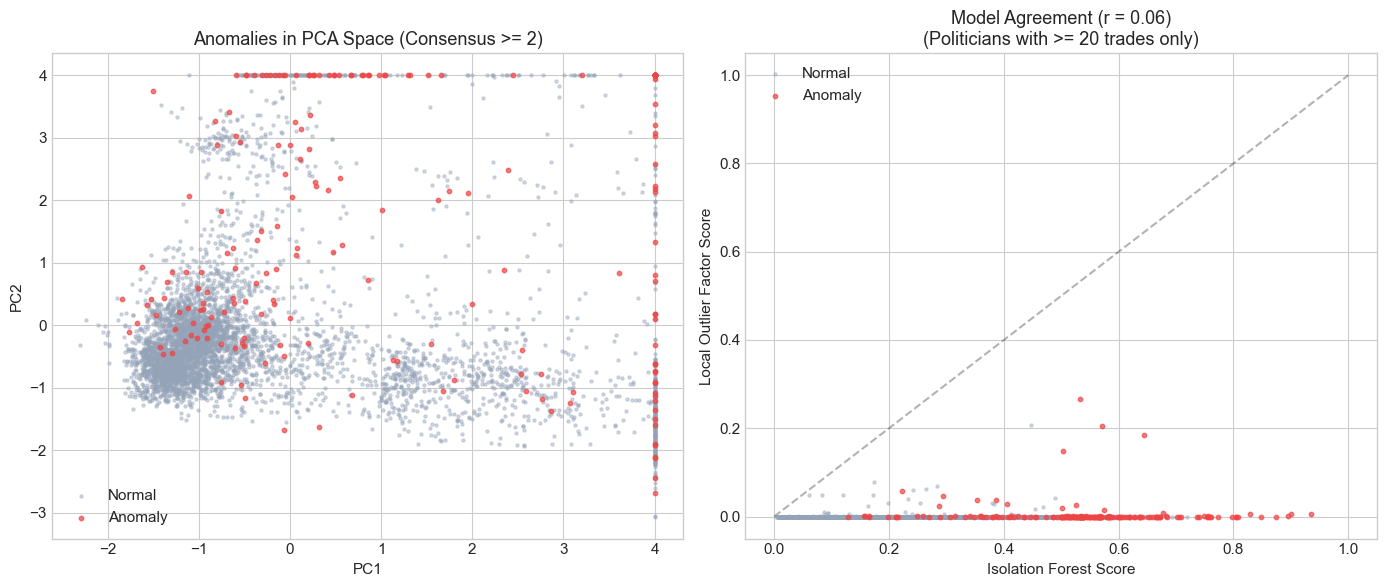

In [10]:
# FIGURE 1: PCA + Model Agreement (filtered for LOF)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sample for speed
df_sample = df_model.sample(n=min(5000, len(df_model)), random_state=42)
normal_mask = df_sample[ANOMALY_COL] == 0
anomaly_mask = df_sample[ANOMALY_COL] == 1

# Left: PCA
axes[0].scatter(df_sample.loc[normal_mask, 'PC1'], df_sample.loc[normal_mask, 'PC2'], c=COLORS['normal'], s=5, alpha=0.4, label='Normal')
axes[0].scatter(df_sample.loc[anomaly_mask, 'PC1'], df_sample.loc[anomaly_mask, 'PC2'], c=COLORS['anomaly'], s=10, alpha=0.7, label='Anomaly')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Anomalies in PCA Space (Consensus >= 2)')
axes[0].legend()

# Right: Model Agreement - FILTER for trades where LOF was computed
df_lof_sample = df_sample[df_sample['lof_computed']]
if len(df_lof_sample) > 0:
    normal_lof = df_lof_sample[df_lof_sample[ANOMALY_COL] == 0]
    anomaly_lof = df_lof_sample[df_lof_sample[ANOMALY_COL] == 1]
    r_corr, _ = pearsonr(df_model[df_model['lof_computed']]['score_if_raw_norm'], df_model[df_model['lof_computed']]['score_lof_contextual_norm'])
    
    axes[1].scatter(normal_lof['score_if_raw_norm'], normal_lof['score_lof_contextual_norm'], c=COLORS['normal'], s=5, alpha=0.4, label='Normal')
    axes[1].scatter(anomaly_lof['score_if_raw_norm'], anomaly_lof['score_lof_contextual_norm'], c=COLORS['anomaly'], s=10, alpha=0.7, label='Anomaly')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[1].set_xlabel('Isolation Forest Score')
    axes[1].set_ylabel('Local Outlier Factor Score')
    axes[1].set_title(f'Model Agreement (r = {r_corr:.2f})\n(Politicians with >= {MIN_TRADES_LOF} trades only)')
    axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_01_pca_model_agreement.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

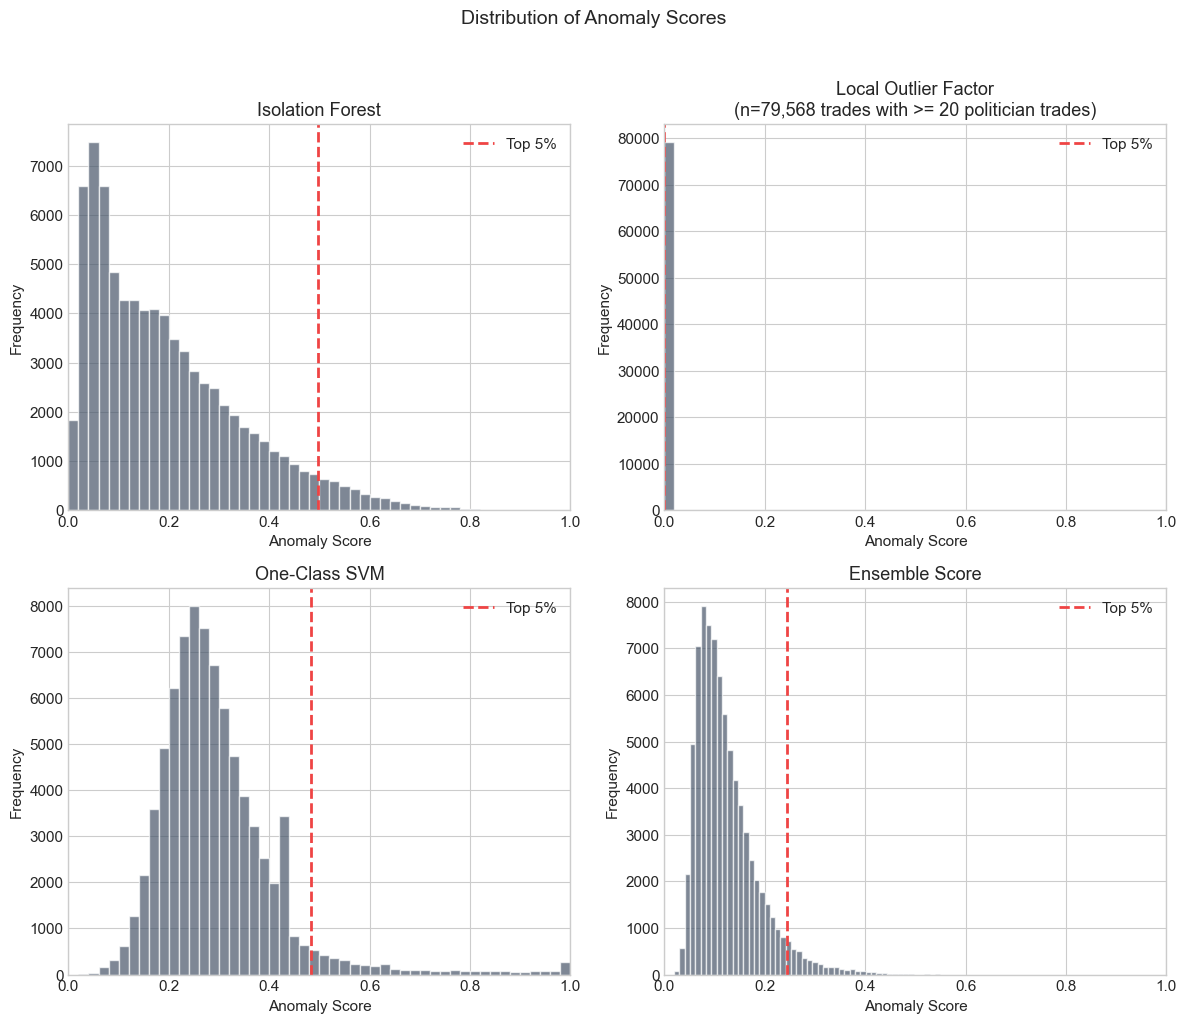

In [11]:
# FIGURE 2: Score Distributions (LOF filtered)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Anomaly Scores', fontsize=14, y=1.02)

# IF - all trades
threshold_if = df_model['score_if_raw_norm'].quantile(0.95)
axes[0,0].hist(df_model['score_if_raw_norm'], bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.7)
axes[0,0].axvline(threshold_if, color=COLORS['anomaly'], linestyle='--', linewidth=2, label='Top 5%')
axes[0,0].set_xlabel('Anomaly Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Isolation Forest')
axes[0,0].legend()
axes[0,0].set_xlim(0, 1)

# LOF - FILTERED for trades where computed
lof_scores = df_model[df_model['lof_computed']]['score_lof_contextual_norm']
threshold_lof = lof_scores.quantile(0.95)
axes[0,1].hist(lof_scores, bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.7)
axes[0,1].axvline(threshold_lof, color=COLORS['anomaly'], linestyle='--', linewidth=2, label='Top 5%')
axes[0,1].set_xlabel('Anomaly Score')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title(f'Local Outlier Factor\n(n={len(lof_scores):,} trades with >= {MIN_TRADES_LOF} politician trades)')
axes[0,1].legend()
axes[0,1].set_xlim(0, 1)

# SVM - all trades
threshold_svm = df_model['score_svm_raw_norm'].quantile(0.95)
axes[1,0].hist(df_model['score_svm_raw_norm'], bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.7)
axes[1,0].axvline(threshold_svm, color=COLORS['anomaly'], linestyle='--', linewidth=2, label='Top 5%')
axes[1,0].set_xlabel('Anomaly Score')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('One-Class SVM')
axes[1,0].legend()
axes[1,0].set_xlim(0, 1)

# Ensemble - all trades
threshold_ens = df_model['anomaly_score_ensemble'].quantile(0.95)
axes[1,1].hist(df_model['anomaly_score_ensemble'], bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.7)
axes[1,1].axvline(threshold_ens, color=COLORS['anomaly'], linestyle='--', linewidth=2, label='Top 5%')
axes[1,1].set_xlabel('Anomaly Score')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Ensemble Score')
axes[1,1].legend()
axes[1,1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_02_score_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

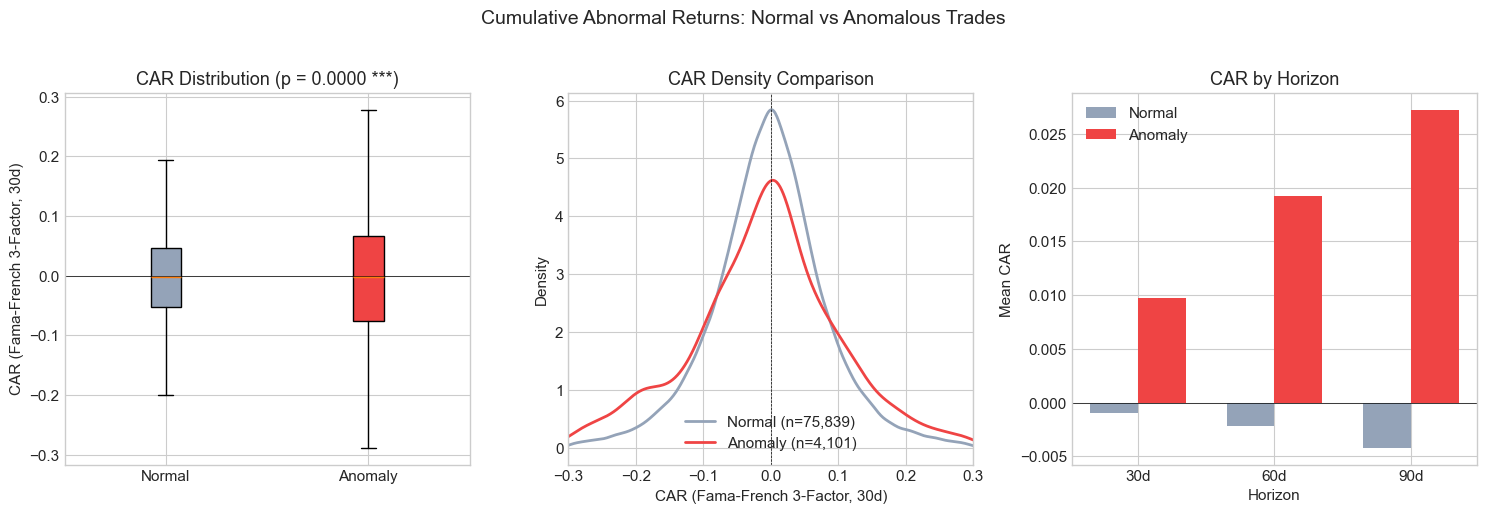


CAR Validation Results:
   Normal mean CAR: -0.0010
   Anomaly mean CAR: 0.0097
   Difference: 0.0108
   t-statistic: 5.94, p-value: 0.0000 ***


In [12]:
# FIGURE 3: CAR Validation
main_car = 'car_ff3_30d' if 'car_ff3_30d' in df_model.columns else 'car_raw_30d'
normal_car = df_model[df_model[ANOMALY_COL]==0][main_car].dropna()
anomaly_car = df_model[df_model[ANOMALY_COL]==1][main_car].dropna()
t_stat, p_val = ttest_ind(anomaly_car, normal_car)
sig = '***' if p_val<0.01 else '**' if p_val<0.05 else '*' if p_val<0.1 else ''

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Cumulative Abnormal Returns: Normal vs Anomalous Trades', fontsize=14, y=1.02)

# Boxplot
bp = axes[0].boxplot([normal_car, anomaly_car], labels=['Normal', 'Anomaly'], patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor(COLORS['normal'])
bp['boxes'][1].set_facecolor(COLORS['anomaly'])
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('CAR (Fama-French 3-Factor, 30d)')
axes[0].set_title(f'CAR Distribution (p = {p_val:.4f} {sig})')

# Density
normal_car[(normal_car>=-0.3)&(normal_car<=0.3)].plot.kde(ax=axes[1], color=COLORS['normal'], linewidth=2, label=f'Normal (n={len(normal_car):,})')
anomaly_car[(anomaly_car>=-0.3)&(anomaly_car<=0.3)].plot.kde(ax=axes[1], color=COLORS['anomaly'], linewidth=2, label=f'Anomaly (n={len(anomaly_car):,})')
axes[1].axvline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('CAR (Fama-French 3-Factor, 30d)')
axes[1].set_ylabel('Density')
axes[1].set_title('CAR Density Comparison')
axes[1].legend()
axes[1].set_xlim(-0.3, 0.3)

# By horizon
horizons = ['30d', '60d', '90d']
car_prefix = 'car_ff3' if 'car_ff3_30d' in df_model.columns else 'car_raw'
mn = [df_model[df_model[ANOMALY_COL]==0][f'{car_prefix}_{h}'].mean() for h in horizons if f'{car_prefix}_{h}' in df_model.columns]
ma = [df_model[df_model[ANOMALY_COL]==1][f'{car_prefix}_{h}'].mean() for h in horizons if f'{car_prefix}_{h}' in df_model.columns]
x = np.arange(len(mn))
axes[2].bar(x-0.175, mn, 0.35, label='Normal', color=COLORS['normal'])
axes[2].bar(x+0.175, ma, 0.35, label='Anomaly', color=COLORS['anomaly'])
axes[2].set_xticks(x)
axes[2].set_xticklabels(horizons[:len(mn)])
axes[2].set_xlabel('Horizon')
axes[2].set_ylabel('Mean CAR')
axes[2].set_title('CAR by Horizon')
axes[2].legend()
axes[2].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_03_car_validation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\nCAR Validation Results:')
print(f'   Normal mean CAR: {normal_car.mean():.4f}')
print(f'   Anomaly mean CAR: {anomaly_car.mean():.4f}')
print(f'   Difference: {anomaly_car.mean()-normal_car.mean():.4f}')
print(f'   t-statistic: {t_stat:.2f}, p-value: {p_val:.4f} {sig}')

In [13]:
# CAR Table
print('='*70)
print('CAR COMPARISON: Normal vs Anomalous Trades')
print('='*70)
CAR_COLS = [c for c in df_model.columns if c.startswith('car_') and ('30d' in c or '60d' in c or '90d' in c)]
car_results = []
for car_col in CAR_COLS:
    normal = df_model[df_model[ANOMALY_COL]==0][car_col].dropna()
    anomaly = df_model[df_model[ANOMALY_COL]==1][car_col].dropna()
    if len(normal) < 30 or len(anomaly) < 30: continue
    diff = anomaly.mean() - normal.mean()
    t_stat, p_val = ttest_ind(anomaly, normal)
    pooled_std = np.sqrt((normal.std()**2 + anomaly.std()**2)/2)
    d = diff/pooled_std if pooled_std>0 else 0
    car_results.append({'CAR': car_col, 'Mean_Normal': normal.mean(), 'Mean_Anomaly': anomaly.mean(), 'Difference': diff, 'Cohens_d': d, 'p_value': p_val})
    sig = '***' if p_val<0.01 else '**' if p_val<0.05 else '*' if p_val<0.1 else ''
    print(f'{car_col}: Normal={normal.mean():.4f} Anomaly={anomaly.mean():.4f} Diff={diff:.4f} p={p_val:.4f} {sig}')
car_results_df = pd.DataFrame(car_results)

CAR COMPARISON: Normal vs Anomalous Trades
car_raw_30d: Normal=0.0005 Anomaly=0.0168 Diff=0.0164 p=0.0000 ***
car_capm_30d: Normal=0.0009 Anomaly=0.0113 Diff=0.0104 p=0.0000 ***
car_ff3_30d: Normal=-0.0010 Anomaly=0.0097 Diff=0.0108 p=0.0000 ***
car_raw_60d: Normal=0.0013 Anomaly=0.0354 Diff=0.0342 p=0.0000 ***
car_capm_60d: Normal=0.0019 Anomaly=0.0241 Diff=0.0222 p=0.0000 ***
car_ff3_60d: Normal=-0.0021 Anomaly=0.0192 Diff=0.0214 p=0.0000 ***
car_raw_90d: Normal=-0.0004 Anomaly=0.0478 Diff=0.0482 p=0.0000 ***
car_capm_90d: Normal=0.0011 Anomaly=0.0321 Diff=0.0311 p=0.0000 ***
car_ff3_90d: Normal=-0.0042 Anomaly=0.0272 Diff=0.0314 p=0.0000 ***


## 5. Profiling

In [14]:
politician_stats = df_model.groupby(['BioGuideID', 'Name', 'Party', 'Chamber']).agg({ANOMALY_COL: ['sum', 'mean'], 'trade_id': 'count', 'car_ff3_30d': 'mean'}).reset_index()
politician_stats.columns = ['BioGuideID', 'Name', 'Party', 'Chamber', 'Anomaly_Count', 'Anomaly_Rate', 'Total_Trades', 'Avg_CAR']
politician_stats = politician_stats[politician_stats['Total_Trades'] >= 20].sort_values('Anomaly_Rate', ascending=False)
print('Top 15 Politicians by Anomaly Rate:')
print(politician_stats.head(15)[['Name', 'Party', 'Anomaly_Rate', 'Total_Trades', 'Avg_CAR']].to_string(index=False))

Top 15 Politicians by Anomaly Rate:
            Name Party  Anomaly_Rate  Total_Trades   Avg_CAR
    Nancy Pelosi     D      0.507353           136  0.007334
   Daniel Meuser     R      0.463768            69  0.010876
  James E. Banks     R      0.320000            25 -0.075378
     Smith, Tina     D      0.318182            22  0.043463
   Mark Dr Green     R      0.316279           215  0.006870
  Tom Malinowski     D      0.299020           204 -0.021476
  Adam Kinzinger     R      0.290323            31 -0.042987
Moody, Ashley B.     R      0.285714            21  0.000106
       Tim Moore     R      0.275449           167  0.004392
      Brian Mast     R      0.274194            62  0.015869
  Roger Williams     R      0.272727            22  0.020372
 Loeffler, Kelly     R      0.265060           249 -0.013073
     Sheri Biggs     R      0.263889            72 -0.007021
      Mark Green     R      0.262195           164 -0.068154
  Kim Dr Schrier     D      0.259259            2

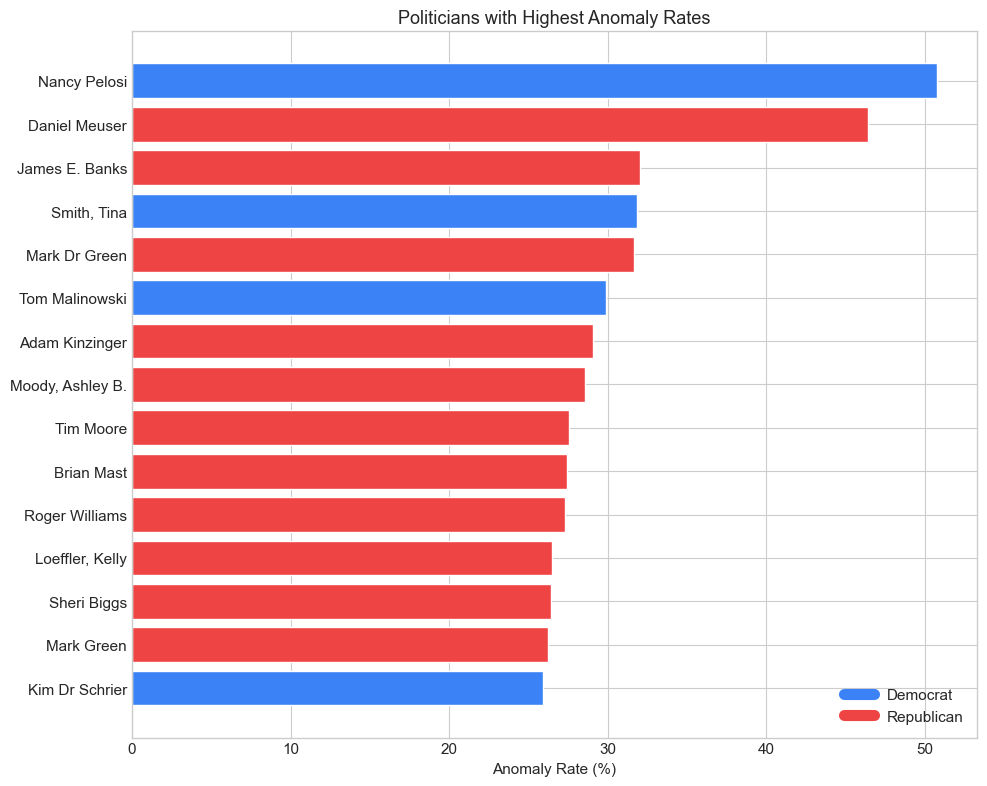

In [15]:
# FIGURE 4: Top Politicians
top15 = politician_stats.head(15)
fig, ax = plt.subplots(figsize=(10, 8))
colors = [COLORS['dem'] if p=='D' else COLORS['rep'] if p=='R' else COLORS['secondary'] for p in top15['Party']]
ax.barh(range(len(top15)), top15['Anomaly_Rate']*100, color=colors, edgecolor='white')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Name'])
ax.set_xlabel('Anomaly Rate (%)')
ax.set_title('Politicians with Highest Anomaly Rates')
ax.invert_yaxis()
legend_elements = [Line2D([0], [0], color=COLORS['dem'], lw=8, label='Democrat'),
                   Line2D([0], [0], color=COLORS['rep'], lw=8, label='Republican')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_04_top_politicians.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

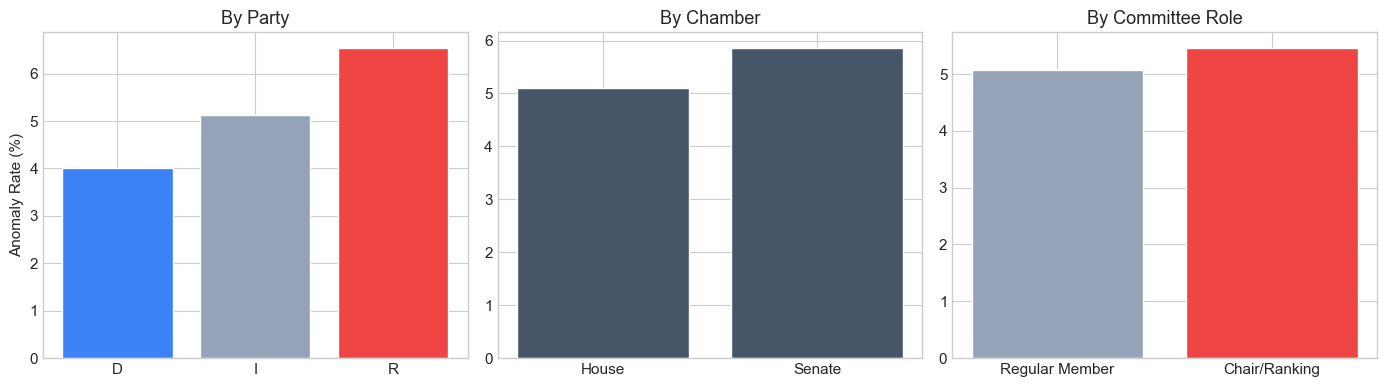

In [16]:
# FIGURE 5: By Group
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

party_data = df_model.groupby('Party')[ANOMALY_COL].mean()*100
party_colors = [COLORS['dem'] if p=='D' else COLORS['rep'] if p=='R' else COLORS['secondary'] for p in party_data.index]
axes[0].bar(party_data.index, party_data.values, color=party_colors, edgecolor='white')
axes[0].set_ylabel('Anomaly Rate (%)')
axes[0].set_title('By Party')

chamber_data = df_model.groupby('Chamber')[ANOMALY_COL].mean()*100
axes[1].bar(chamber_data.index, chamber_data.values, color=COLORS['primary'], edgecolor='white')
axes[1].set_title('By Chamber')

if 'is_chair_or_ranking' in df_model.columns:
    role_data = df_model.groupby('is_chair_or_ranking')[ANOMALY_COL].mean()*100
    axes[2].bar(['Regular Member', 'Chair/Ranking'], role_data.values, color=[COLORS['secondary'], COLORS['anomaly']], edgecolor='white')
    axes[2].set_title('By Committee Role')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_05_anomaly_by_group.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

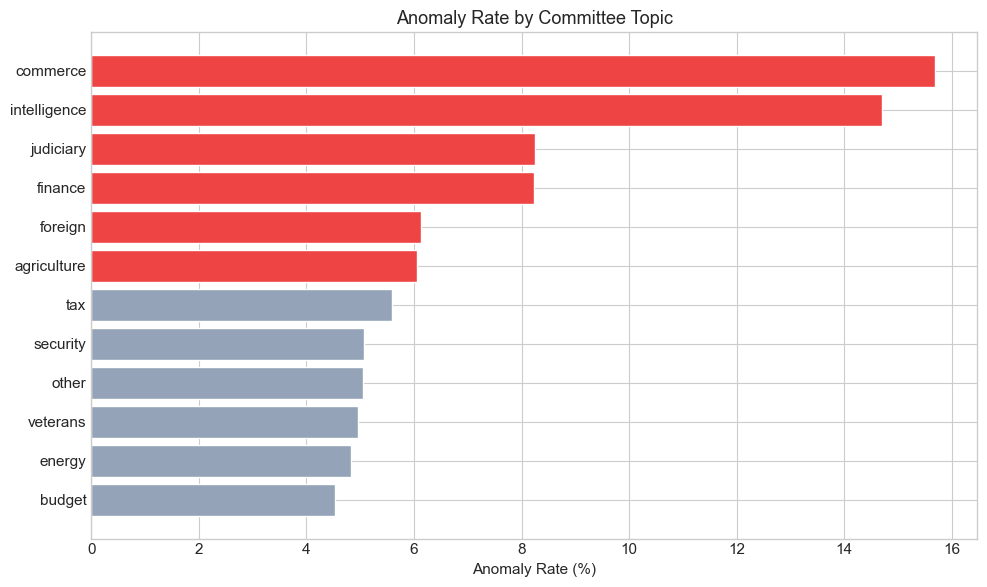

In [17]:
# FIGURE 6: By Committee
if 'committee_topic' in df_model.columns:
    comm_stats = df_model.groupby('committee_topic')[ANOMALY_COL].agg(['mean', 'count'])
    comm_stats = comm_stats[comm_stats['count']>=100].sort_values('mean', ascending=False).head(12)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [COLORS['anomaly'] if r > comm_stats['mean'].median() else COLORS['normal'] for r in comm_stats['mean']]
    ax.barh(range(len(comm_stats)), comm_stats['mean']*100, color=colors, edgecolor='white')
    ax.set_yticks(range(len(comm_stats)))
    ax.set_yticklabels(comm_stats.index)
    ax.set_xlabel('Anomaly Rate (%)')
    ax.set_title('Anomaly Rate by Committee Topic')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig_06_anomaly_by_committee.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

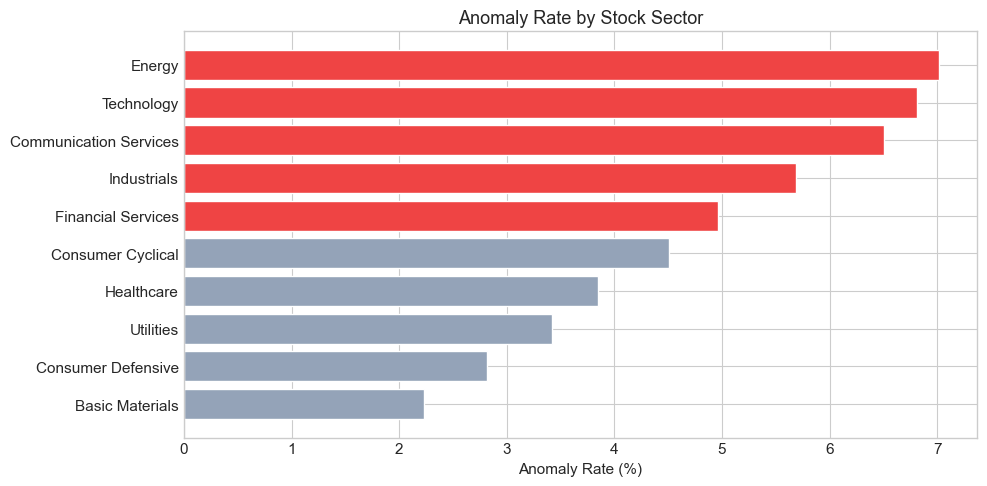

In [18]:
# FIGURE 7: By Sector
if 'sector' in df_model.columns:
    sector_stats = df_model.groupby('sector')[ANOMALY_COL].agg(['mean', 'count'])
    sector_stats = sector_stats[sector_stats['count']>=100].sort_values('mean', ascending=False).head(10)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [COLORS['anomaly'] if r > sector_stats['mean'].median() else COLORS['normal'] for r in sector_stats['mean']]
    ax.barh(range(len(sector_stats)), sector_stats['mean']*100, color=colors, edgecolor='white')
    ax.set_yticks(range(len(sector_stats)))
    ax.set_yticklabels(sector_stats.index)
    ax.set_xlabel('Anomaly Rate (%)')
    ax.set_title('Anomaly Rate by Stock Sector')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig_07_anomaly_by_sector.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

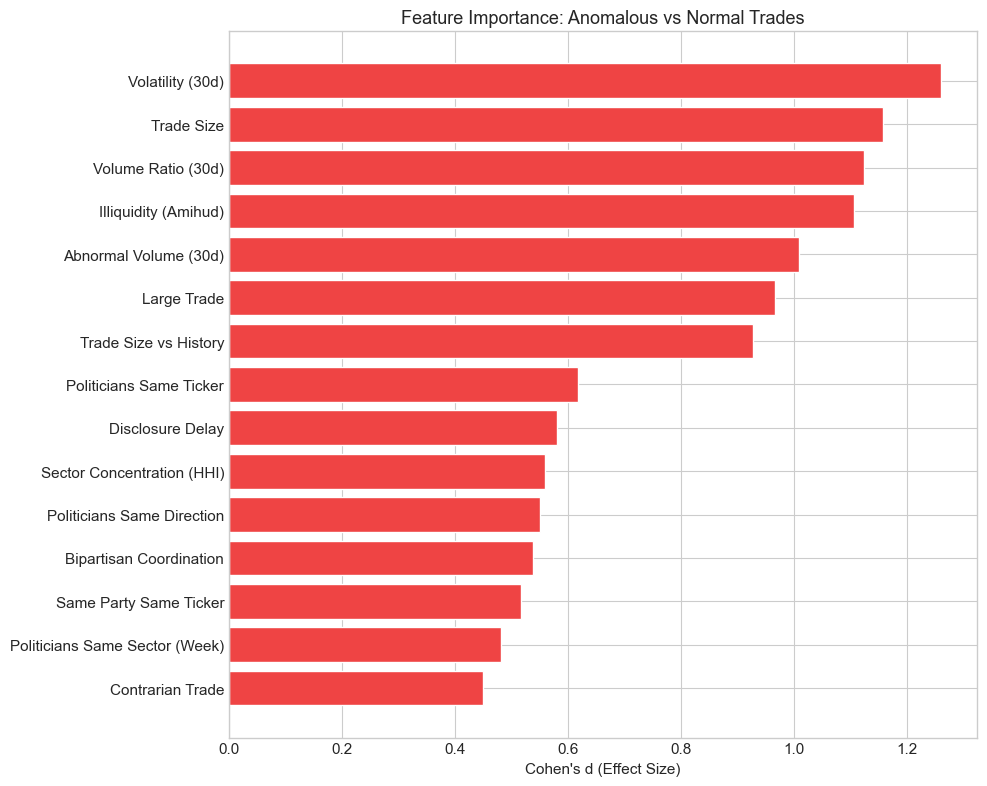

In [19]:
# FIGURE 8: Feature Importance
feat_comp = []
for f in FEATURES_ALL:
    n_mean = df_model[df_model[ANOMALY_COL]==0][f].mean()
    a_mean = df_model[df_model[ANOMALY_COL]==1][f].mean()
    std = df_model[f].std()
    d = (a_mean - n_mean)/std if std>0 else 0
    feat_comp.append({'Feature': f, 'Label': get_label(f), 'Cohens_d': d})
feat_df = pd.DataFrame(feat_comp).sort_values('Cohens_d', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [COLORS['anomaly'] if d>0 else COLORS['dem'] for d in feat_df['Cohens_d']]
ax.barh(range(len(feat_df)), feat_df['Cohens_d'], color=colors, edgecolor='white')
ax.set_yticks(range(len(feat_df)))
ax.set_yticklabels(feat_df['Label'])
ax.set_xlabel("Cohen's d (Effect Size)")
ax.set_title('Feature Importance: Anomalous vs Normal Trades')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_08_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

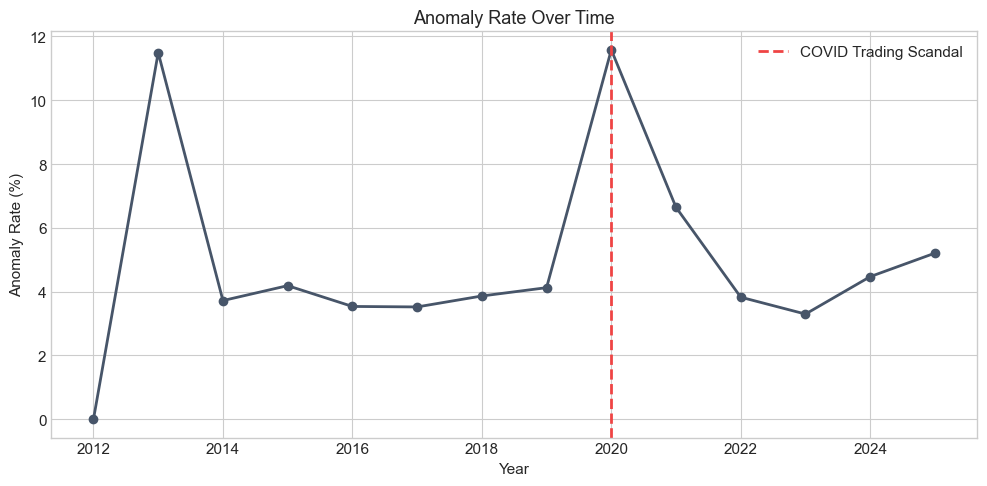

In [20]:
# FIGURE 9: Temporal
df_model['trade_year'] = df_model['trade_date'].dt.year
year_data = df_model.groupby('trade_year')[ANOMALY_COL].mean()*100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(year_data.index, year_data.values, marker='o', linewidth=2, color=COLORS['primary'])
ax.axvline(2020, color=COLORS['anomaly'], linestyle='--', linewidth=2, label='COVID Trading Scandal')
ax.set_xlabel('Year')
ax.set_ylabel('Anomaly Rate (%)')
ax.set_title('Anomaly Rate Over Time')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_09_temporal.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

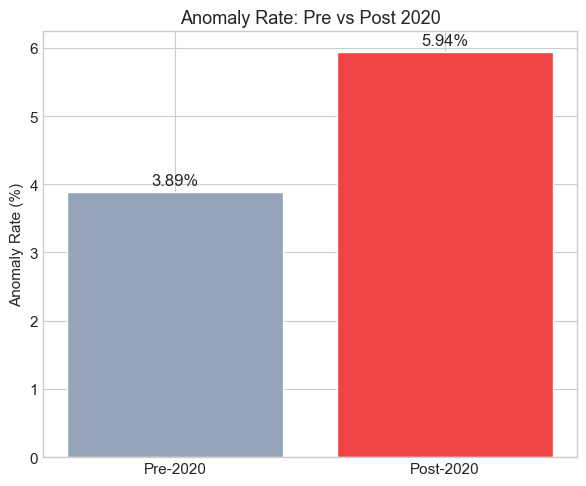

In [21]:
# FIGURE 10: Pre vs Post 2020
pre = df_model[df_model['trade_year']<2020][ANOMALY_COL].mean()*100
post = df_model[df_model['trade_year']>=2020][ANOMALY_COL].mean()*100

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Pre-2020', 'Post-2020'], [pre, post], color=[COLORS['normal'], COLORS['anomaly']], edgecolor='white')
ax.set_ylabel('Anomaly Rate (%)')
ax.set_title('Anomaly Rate: Pre vs Post 2020')
for i, v in enumerate([pre, post]):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_10_pre_post_2020.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [22]:
# Robustness
print('\nRobustness Check: Sensitivity to Contamination Rate')
print('='*70)
X_robust = scaler.fit_transform(df_model[FEATURES_POINT])
for cont in [0.03, 0.05, 0.07, 0.10]:
    clf = IsolationForest(contamination=cont, n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    labels = clf.fit_predict(X_robust) == -1
    car_n = df_model.loc[~labels, 'car_ff3_30d'].mean()
    car_a = df_model.loc[labels, 'car_ff3_30d'].mean()
    print(f'Contamination {cont:.0%}: N_anom={labels.sum():,} CAR_normal={car_n:.4f} CAR_anomaly={car_a:.4f} Diff={car_a-car_n:.4f}')


Robustness Check: Sensitivity to Contamination Rate
Contamination 3%: N_anom=2,402 CAR_normal=-0.0011 CAR_anomaly=0.0203 Diff=0.0214
Contamination 5%: N_anom=4,004 CAR_normal=-0.0014 CAR_anomaly=0.0177 Diff=0.0191
Contamination 7%: N_anom=5,606 CAR_normal=-0.0016 CAR_anomaly=0.0151 Diff=0.0167
Contamination 10%: N_anom=8,008 CAR_normal=-0.0017 CAR_anomaly=0.0111 Diff=0.0128


## 6. Export

In [23]:
out_cols = ['trade_id', 'BioGuideID', 'Name', 'Party', 'Chamber', 'Ticker', 'trade_date', 'Transaction', 'Trade_Size_USD', 'sector', 'anomaly_if', 'anomaly_svm', 'anomaly_lof_contextual', 'anomaly_collective', 'anomaly_vote_count', 'anomaly_consensus_2', 'anomaly_score_ensemble', 'car_ff3_30d', 'car_ff3_60d', 'car_ff3_90d']
out_cols = [c for c in out_cols if c in df_model.columns]
df_model[out_cols].to_csv(f'{OUTPUT_DIR}/anomaly_detection_results.csv', index=False)
politician_stats.to_csv(f'{OUTPUT_DIR}/politician_anomaly_summary.csv', index=False)
car_results_df.to_csv(f'{OUTPUT_DIR}/car_validation_results.csv', index=False)
print(f'Saved to: {OUTPUT_DIR}')

Saved to: C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection


In [24]:
print('\n' + '='*70)
print('SUMMARY')
print('='*70)
print(f'Total trades: {len(df_model):,}')
print(f'Trades with LOF computed: {df_model["lof_computed"].sum():,} ({df_model["lof_computed"].mean():.1%})')
print(f'Anomalies (>=2 methods): {df_model[ANOMALY_COL].sum():,} ({df_model[ANOMALY_COL].mean():.1%})')
print(f'CAR Normal: {df_model[df_model[ANOMALY_COL]==0]["car_ff3_30d"].mean():.4f}')
print(f'CAR Anomaly: {df_model[df_model[ANOMALY_COL]==1]["car_ff3_30d"].mean():.4f}')
print(f'\nFigures saved: fig_01 to fig_10 (.png)')


SUMMARY
Total trades: 80,080
Trades with LOF computed: 79,568 (99.4%)
Anomalies (>=2 methods): 4,144 (5.2%)
CAR Normal: -0.0010
CAR Anomaly: 0.0097

Figures saved: fig_01 to fig_10 (.png)
